<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_15_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
veri = pd.read_csv("/content/kredi_basvurulari.csv")

In [66]:
veri.head()

,yas,aylik_gelir,calisma_yili,kredi_tutari,vade_ay,borc_gelir_orani,gecmis_gecikme,ev_durumu,kredi_amaci,basvuru_gunu,kredi_durumu
0,41,34300,6,68000,60,0.05,0,Aile yani,Egitim,Paz,Odedi
1,28,31100,3,327000,24,0.20,1,Kira,Tasit,Cum,Odedi
2,46,51100,14,118000,12,0.11,1,Ev sahibi,Tasit,Car,Odedi
3,47,47000,16,332000,36,0.42,0,Aile yani,Konut,Car,Odedi
4,21,22300,0,139000,36,0.03,1,Aile yani,Tasit,Cmt,Odedi


In [67]:
veri.shape

(2000, 11)

In [68]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   yas               2000 non-null   int64  
 1   aylik_gelir       2000 non-null   int64  
 2   calisma_yili      2000 non-null   int64  
 3   kredi_tutari      2000 non-null   int64  
 4   vade_ay           2000 non-null   int64  
 5   borc_gelir_orani  2000 non-null   float64
 6   gecmis_gecikme    2000 non-null   int64  
 7   ev_durumu         2000 non-null   object 
 8   kredi_amaci       2000 non-null   object 
 9   basvuru_gunu      2000 non-null   object 
 10  kredi_durumu      2000 non-null   object 
dtypes: float64(1), int64(6), object(4)
memory usage: 172.0+ KB


In [69]:
veri.isnull().sum()

,0
yas,0
aylik_gelir,0
calisma_yili,0
kredi_tutari,0
vade_ay,0
borc_gelir_orani,0
gecmis_gecikme,0
ev_durumu,0
kredi_amaci,0
basvuru_gunu,0


In [70]:
veri.describe()

,yas,aylik_gelir,calisma_yili,kredi_tutari,vade_ay,borc_gelir_orani,gecmis_gecikme
count,2000.00000,2000.00000,2000.000000,2.000000e+03,2000.000000,2000.000000,2000.000000
mean,37.65800,46855.25000,8.197500,3.159695e+05,34.608000,0.300495,0.735500
std,9.55896,22270.02738,6.515882,2.136870e+05,14.673854,0.159396,0.867131
min,21.00000,17000.00000,0.000000,2.900000e+04,12.000000,0.010000,0.000000
25%,31.00000,31075.00000,3.000000,1.607500e+05,24.000000,0.180000,0.000000
50%,38.00000,42300.00000,7.000000,2.650000e+05,36.000000,0.280000,1.000000
75%,44.00000,57100.00000,12.000000,4.202500e+05,48.000000,0.400000,1.000000
max,68.00000,168600.00000,37.000000,1.670000e+06,60.000000,0.880000,5.000000


In [71]:
# Hedef değişken ="kredi durumu" yüzdelik ve adet olarak.
veri["kredi_durumu"].value_counts()

,count
kredi_durumu,
Odedi,1493
Temerrut,507


In [72]:
veri["kredi_durumu"].value_counts(normalize=True).round(2)

,proportion
kredi_durumu,
Odedi,0.75
Temerrut,0.25


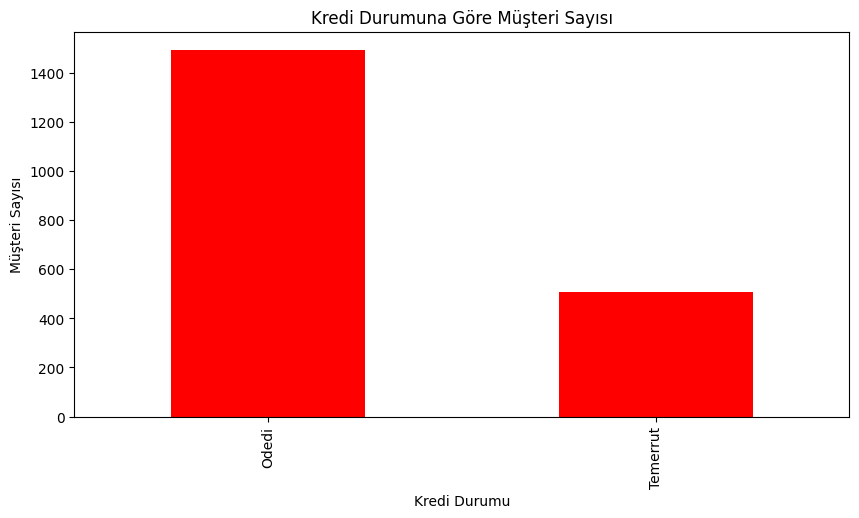

In [73]:
plt.figure(figsize=(10,5))
veri["kredi_durumu"].value_counts().plot(kind="bar", color="r")
plt.title("Kredi Durumuna Göre Müşteri Sayısı")
plt.xlabel("Kredi Durumu")
plt.ylabel("Müşteri Sayısı")
plt.show()


In [74]:
#geçmiş gecikmelere analizi

gecikme_tablosu = pd.crosstab(veri['gecmis_gecikme'], veri['kredi_durumu'])
gecikme_tablosu

kredi_durumu,Odedi,Temerrut
gecmis_gecikme,,
0,777,184
1,565,145
2,120,126
3,27,38
4,4,12
5,0,2


In [75]:
gecikme_tablosu = pd.crosstab(veri['gecmis_gecikme'], veri['kredi_durumu'], normalize="index").round(2)
gecikme_tablosu

kredi_durumu,Odedi,Temerrut
gecmis_gecikme,,
0,0.81,0.19
1,0.80,0.20
2,0.49,0.51
3,0.42,0.58
4,0.25,0.75
5,0.00,1.00


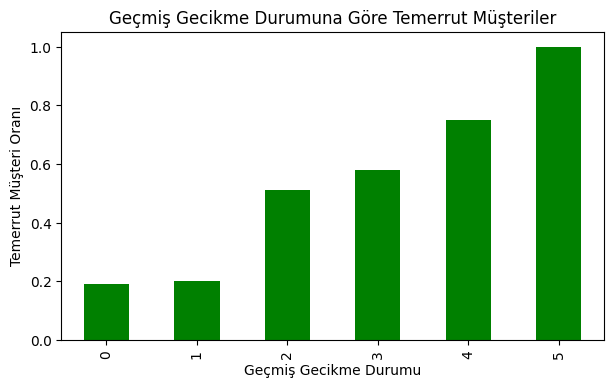

In [76]:
plt.figure(figsize=(7,4))
gecikme_tablosu["Temerrut"].plot(kind="bar", color="g")
plt.title("Geçmiş Gecikme Durumuna Göre Temerrut Müşteriler")
plt.xlabel("Geçmiş Gecikme Durumu")
plt.ylabel("Temerrut Müşteri Oranı")
plt.show()

In [77]:
# Ev durumu ve kredi amacı ile kredi ödeme durumu analiz tablosu.
ev_tablosu = pd.crosstab(veri["ev_durumu"], veri["kredi_durumu"])
ev_tablosu


kredi_durumu,Odedi,Temerrut
ev_durumu,,
Aile yani,256,85
Ev sahibi,568,110
Kira,669,312


In [78]:
ev_tablosu = pd.crosstab(veri["ev_durumu"], veri["kredi_durumu"],normalize="index").round(2)
ev_tablosu

kredi_durumu,Odedi,Temerrut
ev_durumu,,
Aile yani,0.75,0.25
Ev sahibi,0.84,0.16
Kira,0.68,0.32


In [79]:
amac_tablosu = pd.crosstab(veri["kredi_amaci"], veri["kredi_durumu"])
amac_tablosu

kredi_durumu,Odedi,Temerrut
kredi_amaci,,
Egitim,179,42
Ihtiyac,634,287
Konut,318,62
Tasit,362,116


In [80]:
amac_tablosu = pd.crosstab(veri["kredi_amaci"], veri["kredi_durumu"],normalize="index").round(2)
amac_tablosu

kredi_durumu,Odedi,Temerrut
kredi_amaci,,
Egitim,0.81,0.19
Ihtiyac,0.69,0.31
Konut,0.84,0.16
Tasit,0.76,0.24


In [81]:
gun_tablosu = pd.crosstab(veri["basvuru_gunu"], veri["kredi_durumu"])
gun_tablosu

kredi_durumu,Odedi,Temerrut
basvuru_gunu,,
Car,218,72
Cmt,230,80
Cum,199,65
Paz,213,79
Per,219,80
Pzt,209,50
Sal,205,81


In [82]:
gun_tablosu = pd.crosstab(veri["basvuru_gunu"], veri["kredi_durumu"],normalize="index").round(2)
gun_tablosu

kredi_durumu,Odedi,Temerrut
basvuru_gunu,,
Car,0.75,0.25
Cmt,0.74,0.26
Cum,0.75,0.25
Paz,0.73,0.27
Per,0.73,0.27
Pzt,0.81,0.19
Sal,0.72,0.28


In [83]:
veri.head()

,yas,aylik_gelir,calisma_yili,kredi_tutari,vade_ay,borc_gelir_orani,gecmis_gecikme,ev_durumu,kredi_amaci,basvuru_gunu,kredi_durumu
0,41,34300,6,68000,60,0.05,0,Aile yani,Egitim,Paz,Odedi
1,28,31100,3,327000,24,0.20,1,Kira,Tasit,Cum,Odedi
2,46,51100,14,118000,12,0.11,1,Ev sahibi,Tasit,Car,Odedi
3,47,47000,16,332000,36,0.42,0,Aile yani,Konut,Car,Odedi
4,21,22300,0,139000,36,0.03,1,Aile yani,Tasit,Cmt,Odedi


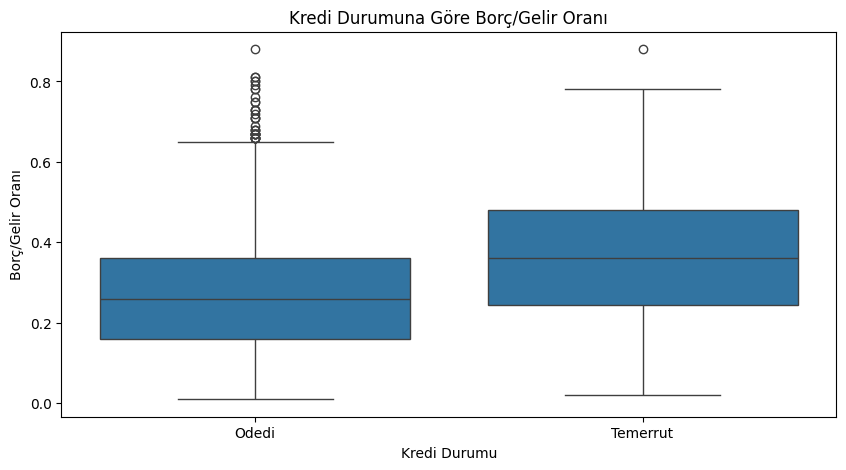

In [84]:
plt.figure(figsize=(10,5))
sns.boxplot(data=veri, x="kredi_durumu", y="borc_gelir_orani")
plt.title("Kredi Durumuna Göre Borç/Gelir Oranı")
plt.xlabel("Kredi Durumu")
plt.ylabel("Borç/Gelir Oranı")
plt.show()

In [85]:
veri["aylik_taksit"] = veri['kredi_tutari'] / veri['vade_ay']

In [86]:
veri.head()

,yas,aylik_gelir,calisma_yili,kredi_tutari,vade_ay,borc_gelir_orani,gecmis_gecikme,ev_durumu,kredi_amaci,basvuru_gunu,kredi_durumu,aylik_taksit
0,41,34300,6,68000,60,0.05,0,Aile yani,Egitim,Paz,Odedi,1133.333333
1,28,31100,3,327000,24,0.20,1,Kira,Tasit,Cum,Odedi,13625.000000
2,46,51100,14,118000,12,0.11,1,Ev sahibi,Tasit,Car,Odedi,9833.333333
3,47,47000,16,332000,36,0.42,0,Aile yani,Konut,Car,Odedi,9222.222222
4,21,22300,0,139000,36,0.03,1,Aile yani,Tasit,Cmt,Odedi,3861.111111


In [87]:
taksit_orani = veri["aylik_taksit"] / veri['aylik_gelir']
taksit_orani

,0
0,0.033042
1,0.438103
2,0.192433
3,0.196217
4,0.173144
...,...
1995,0.560949
1996,0.354355
1997,0.214982
1998,0.128715


In [88]:
veri["toplam_borc_yuku"] = veri['borc_gelir_orani'] + taksit_orani
veri.head()

,yas,aylik_gelir,calisma_yili,kredi_tutari,vade_ay,borc_gelir_orani,gecmis_gecikme,ev_durumu,kredi_amaci,basvuru_gunu,kredi_durumu,aylik_taksit,toplam_borc_yuku
0,41,34300,6,68000,60,0.05,0,Aile yani,Egitim,Paz,Odedi,1133.333333,0.083042
1,28,31100,3,327000,24,0.20,1,Kira,Tasit,Cum,Odedi,13625.000000,0.638103
2,46,51100,14,118000,12,0.11,1,Ev sahibi,Tasit,Car,Odedi,9833.333333,0.302433
3,47,47000,16,332000,36,0.42,0,Aile yani,Konut,Car,Odedi,9222.222222,0.616217
4,21,22300,0,139000,36,0.03,1,Aile yani,Tasit,Cmt,Odedi,3861.111111,0.203144


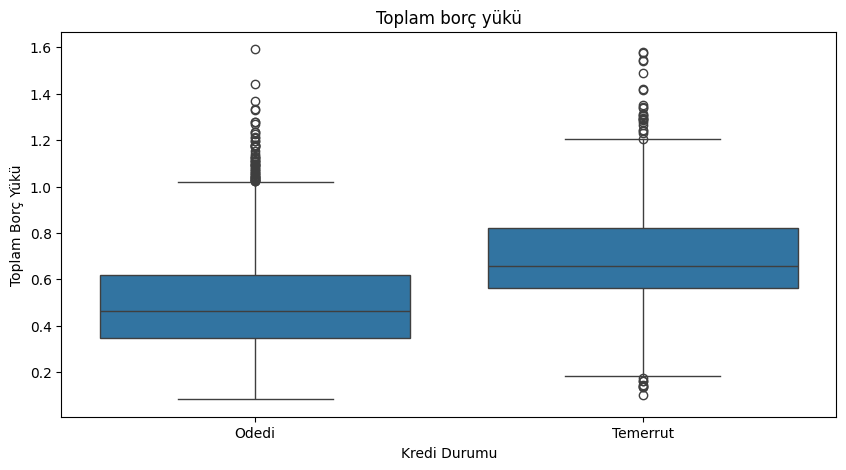

In [89]:
plt.figure(figsize=(10,5))
sns.boxplot(data=veri, x="kredi_durumu", y="toplam_borc_yuku")
plt.title("Toplam borç yükü")
plt.xlabel("Kredi Durumu")
plt.ylabel("Toplam Borç Yükü")
plt.show()

In [90]:
# Modele Hazırlık
veri = pd.get_dummies(veri, columns=["ev_durumu", "kredi_amaci", "basvuru_gunu"], drop_first=True, dtype=int)
#

In [92]:
print(veri.shape)
print(veri.columns.to_list())

(2000, 21)
['yas', 'aylik_gelir', 'calisma_yili', 'kredi_tutari', 'vade_ay', 'borc_gelir_orani', 'gecmis_gecikme', 'kredi_durumu', 'aylik_taksit', 'toplam_borc_yuku', 'ev_durumu_Ev sahibi', 'ev_durumu_Kira', 'kredi_amaci_Ihtiyac', 'kredi_amaci_Konut', 'kredi_amaci_Tasit', 'basvuru_gunu_Cmt', 'basvuru_gunu_Cum', 'basvuru_gunu_Paz', 'basvuru_gunu_Per', 'basvuru_gunu_Pzt', 'basvuru_gunu_Sal']


In [95]:
from sklearn.preprocessing import LabelEncoder # bu işlemi bu algoritma için yapmasakta olurdu. ağaç yapısında hedef sütunu metinsel olsada algılayacaktı. hata vermezdi.
kodlayici = LabelEncoder()
veri["kredi_durumu"] = kodlayici.fit_transform(veri["kredi_durumu"])
veri["kredi_durumu"].value_counts()

,count
kredi_durumu,
0,1493
1,507


In [99]:
X = veri.drop(columns=["kredi_durumu"])
y = veri["kredi_durumu"]

print(X.shape)
print(y.shape)

(2000, 20)
(2000,)


In [101]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [105]:
print("Eğitim:", X_train.shape)
print("Test:", X_test.shape)

Eğitim: (1500, 20)
Test: (500, 20)


In [107]:
naif_dogruluk = 1 - y_test.mean() # referans noktası yani biz ortalamalara bakarak bile bir tahmin yapsak 0,74 ödeyecek deriz.
print("Naif Doğruluk Oranı:", naif_dogruluk)

Naif Doğruluk Oranı: 0.746


In [112]:
# Tek başına bir karar kütüğü, ana mantığı anlatmak için kurduk. Adaboost un temeli, tek ağaçlardan ulaşan yapılar.

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,recall_score, confusion_matrix

kutuk = DecisionTreeClassifier(max_depth=1 ,random_state=42)
kutuk.fit(X_train, y_train)
kutuk_tahmin = kutuk.predict(X_test)

print("Doğruluk Oranı:", accuracy_score(y_test, kutuk_tahmin))
print("Doğal Olumlu Oranı:", recall_score(y_test, kutuk_tahmin))

#kütük hangi soruyu sordu.
soru_sutunu = X.columns[kutuk.tree_.feature[0]]
print("kutugun sordugu soru:", soru_sutunu)

Doğruluk Oranı: 0.746
Doğal Olumlu Oranı: 0.0
kutugun sordugu soru: toplam_borc_yuku


In [114]:
# ADABOOST

from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train, y_train)


AdaBoostClassifier(random_state=42)

In [117]:
ada_tahmin = ada.predict(X_test)

In [123]:
print("Eğitim Doğruluk:", ada.score(X_train, y_train))
print("Test Doğruluk:", accuracy_score(y_test, ada_tahmin))

Eğitim Doğruluk: 0.838
Test Doğruluk: 0.838


Kütük adetini 50 olarak alıyor. Doğruluk %74 den %83 lere çıktı. ödemeyenlerin %83 ü doğru yakalanıyor çıkabilir.

In [125]:
# parametreler(n_estimators)

ada_10 = AdaBoostClassifier(n_estimators=10, random_state=42)
ada_10.fit(X_train, y_train)

ada_200 = AdaBoostClassifier(n_estimators=200, random_state=42)
ada_200.fit(X_train, y_train)

ada_1000 = AdaBoostClassifier(n_estimators=1000, random_state=42)
ada_1000.fit(X_train, y_train)

print("10 ağaçta Doğruluk:", ada_10.score(X_train, y_train))
print("200 ağaçta Doğruluk:", ada_200.score(X_train, y_train))
print("1000 ağaçta Doğruluk:", ada_1000.score(X_train, y_train))

print("10 ağaçta Test Doğruluk:", accuracy_score(y_test, ada_10.predict(X_test)))
print("200 ağaçta Test Doğruluk:", accuracy_score(y_test, ada_200.predict(X_test)))
print("1000 ağaçta Test Doğruluk:", accuracy_score(y_test, ada_1000.predict(X_test)))

10 ağaçta Doğruluk: 0.81
200 ağaçta Doğruluk: 0.8506666666666667
1000 ağaçta Doğruluk: 0.8586666666666667
10 ağaçta Test Doğruluk: 0.804
200 ağaçta Test Doğruluk: 0.836
1000 ağaçta Test Doğruluk: 0.838


In [131]:
# parametre (learning_rate)

from sklearn.metrics import roc_auc_score

ada_hizli = AdaBoostClassifier(n_estimators=200, learning_rate=1, random_state=42)
ada_hizli.fit(X_train, y_train)

ada_orta = AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42)
ada_orta.fit(X_train, y_train)

ada_yavas = AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
ada_yavas.fit(X_train, y_train)

print("learning rate:1.0:", ada_hizli.score(X_train, y_train))
print("learning rate:0.5:", ada_orta.score(X_train, y_train))
print("learning rate:0.1:", ada_yavas.score(X_train, y_train))

print("Test Doğruluk:1.0:", accuracy_score(y_test, ada_hizli.predict(X_test)))
print("Test Doğruluke:0.5:", accuracy_score(y_test, ada_orta.predict(X_test)))
print("Test Doğruluk:0.1:", accuracy_score(y_test, ada_yavas.predict(X_test)))

print("AUC:1.0:", roc_auc_score(y_test, ada_hizli.predict(X_test)))
print("AUC:0.5:", roc_auc_score(y_test, ada_orta.predict(X_test)))
print("AUC:0.1:", roc_auc_score(y_test, ada_yavas.predict(X_test)))




learning rate:1.0: 0.8506666666666667
learning rate:0.5: 0.8453333333333334
learning rate:0.1: 0.8306666666666667
Test Doğruluk:1.0: 0.836
Test Doğruluke:0.5: 0.846
Test Doğruluk:0.1: 0.842
AUC:1.0: 0.7628506892402525
AUC:0.5: 0.7513774250068607
AUC:0.1: 0.714941630955648


In [133]:
from sklearn.metrics import roc_auc_score

ada_hizli = AdaBoostClassifier(n_estimators=1000, learning_rate=1, random_state=42)
ada_hizli.fit(X_train, y_train)

ada_orta = AdaBoostClassifier(n_estimators=1000, learning_rate=0.5, random_state=42)
ada_orta.fit(X_train, y_train)

ada_yavas = AdaBoostClassifier(n_estimators=1000, learning_rate=0.1, random_state=42)
ada_yavas.fit(X_train, y_train)

print("learning rate:1.0:", ada_hizli.score(X_train, y_train))
print("learning rate:0.5:", ada_orta.score(X_train, y_train))
print("learning rate:0.1:", ada_yavas.score(X_train, y_train))

print("Test Doğruluk:1.0:", accuracy_score(y_test, ada_hizli.predict(X_test)))
print("Test Doğruluk:0.5:", accuracy_score(y_test, ada_orta.predict(X_test)))
print("Test Doğruluk:0.1:", accuracy_score(y_test, ada_yavas.predict(X_test)))

print("AUC:1.0:", roc_auc_score(y_test, ada_hizli.predict(X_test)))
print("AUC:0.5:", roc_auc_score(y_test, ada_orta.predict(X_test)))
print("AUC:0.1:", roc_auc_score(y_test, ada_yavas.predict(X_test)))


learning rate:1.0: 0.8586666666666667
learning rate:0.5: 0.848
learning rate:0.1: 0.844
Test Doğruluk:1.0: 0.838
Test Doğruluk:0.5: 0.848
Test Doğruluk:0.1: 0.846
AUC:1.0: 0.7615946465136898
AUC:0.5: 0.763104008781744
AUC:0.1: 0.7487808997065715


In [140]:
onem = pd.Series(ada_orta.feature_importances_, index=X.columns)
onem = onem.sort_values(ascending=False)

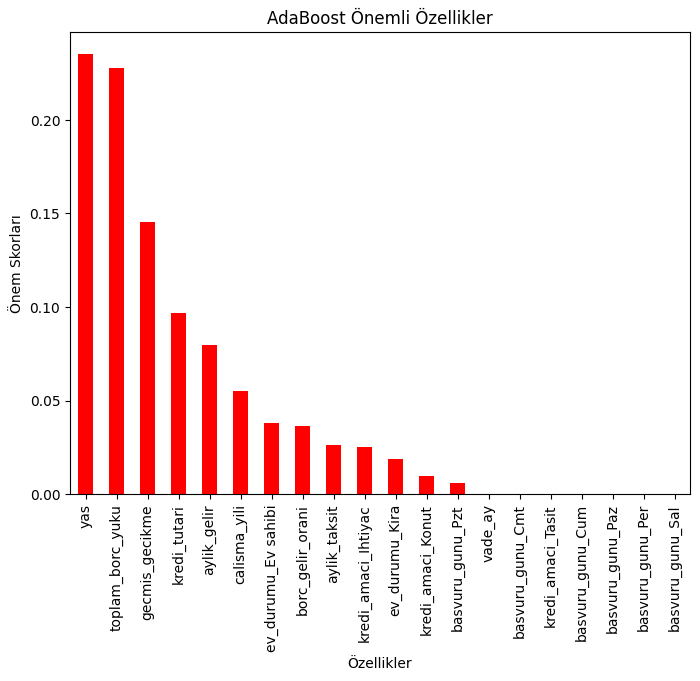

In [141]:
plt.figure(figsize=(8,6))
onem.plot(kind="bar", color="r")
plt.title("AdaBoost Önemli Özellikler")
plt.xlabel("Özellikler")
plt.ylabel("Önem Skorları")
plt.show()

In [ ]:
# ÖDEVLENDİRME: Bu data setimizde yaptığımız ek sütun ekleme işlemini yapmasaydık ve toplam_borc_yuku sütununu eklemeseydik ve algoritmamıza modelimize verimizi bu şekilde verseydik sonuç ne oılurdu? accuracy score ve değişkenlerin etkisini tekrar hesaplayınız.